**Lifetime Value (LTV) Project**

This notebook focuses on forecasting Customer Lifetime Value (LTV) using historical transaction data. The dataset is transformed into time series sequences to capture temporal patterns and customer behavior over time.

Two forecasting approaches are explored:

*   Long Short-Term Memory (LSTM), a recurrent neural network designed for sequential data,
*   TimeFM, a foundation model for time series forecasting.

Their performance is evaluated to assess their effectiveness in projecting future customer value.

## Setup and Dependencies

### Library

Imports the libraries and dependencies required throughout the project.

In [336]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
from google.colab import drive

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### Auth

Authentication to google account and drive for more google cloud services access

In [337]:
drive.mount('/content/drive')

auth.authenticate_user()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Preparation

### Loader

Query for access data in Google BigQuery

Load data from bigquery

In [339]:
df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')
df.head()

/tmp/ipykernel_18195/3670017302.py:1: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')


,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0


In [340]:
df.tail()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
16073,2025-12-05,MDEA,2026-06-02,7,14000.0,DAILYPUSH,714000.0
16074,2025-12-05,MBP,2026-06-02,3,6000.0,DAILYPUSH,584000.0
16075,2025-12-05,MDEA,2026-06-03,2,4000.0,DAILYPUSH,718000.0
16076,2025-12-05,MBP,2026-06-05,0,0.0,PURGE,584000.0
16077,2025-12-05,MDEA,2026-06-05,0,0.0,PURGE,718000.0


### Exploration

Compact information about data

In [341]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16078 entries, 0 to 16077
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        16078 non-null  dbdate 
 1   adnet                  16078 non-null  object 
 2   date_update            16078 non-null  dbdate 
 3   no_of_user             16078 non-null  Int64  
 4   revenue_dailypush      16078 non-null  float64
 5   subject                16078 non-null  object 
 6   revenue_running_total  16078 non-null  float64
dtypes: Int64(1), dbdate(2), float64(2), object(2)
memory usage: 895.1+ KB


Checking unique value

In [342]:
unique_values = df.nunique()
print(unique_values)

date_created_at            42
adnet                       5
date_update               425
no_of_user                435
revenue_dailypush         368
subject                     3
revenue_running_total    5248
dtype: int64


Checking cohort list

In [343]:
sorted(df['date_created_at'].unique())

[datetime.date(2025, 1, 1),
 datetime.date(2025, 1, 7),
 datetime.date(2025, 1, 10),
 datetime.date(2025, 1, 14),
 datetime.date(2025, 1, 20),
 datetime.date(2025, 1, 21),
 datetime.date(2025, 1, 23),
 datetime.date(2025, 1, 28),
 datetime.date(2025, 1, 30),
 datetime.date(2025, 2, 3),
 datetime.date(2025, 2, 8),
 datetime.date(2025, 2, 9),
 datetime.date(2025, 2, 10),
 datetime.date(2025, 2, 14),
 datetime.date(2025, 2, 17),
 datetime.date(2025, 3, 8),
 datetime.date(2025, 3, 26),
 datetime.date(2025, 3, 27),
 datetime.date(2025, 3, 30),
 datetime.date(2025, 4, 21),
 datetime.date(2025, 5, 13),
 datetime.date(2025, 6, 3),
 datetime.date(2025, 6, 24),
 datetime.date(2025, 7, 13),
 datetime.date(2025, 7, 15),
 datetime.date(2025, 7, 18),
 datetime.date(2025, 8, 6),
 datetime.date(2025, 8, 30),
 datetime.date(2025, 9, 2),
 datetime.date(2025, 9, 7),
 datetime.date(2025, 9, 11),
 datetime.date(2025, 9, 17),
 datetime.date(2025, 10, 2),
 datetime.date(2025, 10, 17),
 datetime.date(2025, 10

Checking duplicate data

In [344]:
df.duplicated().sum()

np.int64(0)

### Feature Engineering

Adding cohort age (date update - date created) for getting information day every cohort

In [345]:
df['cohort_age'] = (
    df['date_update'] -
    df['date_created_at']
).dt.days

In [346]:
df.head(10)

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1
5,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1
6,2025-01-01,ADN,2025-01-02,39,78000.0,DAILYPUSH,1132000.0,1
7,2025-01-01,ADN,2025-01-03,292,584000.0,DAILYPUSH,1716000.0,2
8,2025-01-01,C2M,2025-01-03,1,2000.0,DAILYPUSH,8000.0,2
9,2025-01-01,MOBIP,2025-01-03,7,14000.0,DAILYPUSH,98000.0,2


Adding day of week using pandas format (Monday is starting from 0), weekend flag (1 if Saturday/Sunday), and day of month

In [347]:
df['date_created_at'] = pd.to_datetime(df['date_created_at'])
df['date_update'] = pd.to_datetime(df['date_update'])

df['day_of_week'] = df['date_update'].dt.dayofweek
df['weekend'] = (df['date_update'].dt.dayofweek >= 5).astype(int)
df['day_of_month'] = df['date_update'].dt.day

In [348]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,weekend,day_of_month
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0,2,0,1
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,0,1
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0,2,0,1
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0,2,0,1
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1,3,0,2


Checking data information

In [349]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16078 entries, 0 to 16077
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        16078 non-null  datetime64[ns]
 1   adnet                  16078 non-null  object        
 2   date_update            16078 non-null  datetime64[ns]
 3   no_of_user             16078 non-null  Int64         
 4   revenue_dailypush      16078 non-null  float64       
 5   subject                16078 non-null  object        
 6   revenue_running_total  16078 non-null  float64       
 7   cohort_age             16078 non-null  int64         
 8   day_of_week            16078 non-null  int32         
 9   weekend                16078 non-null  int64         
 10  day_of_month           16078 non-null  int32         
dtypes: Int64(1), datetime64[ns](2), float64(2), int32(2), int64(2), object(2)
memory usage: 1.2+ MB


### Visualization

Distribution of cohort length

In [350]:
cohort_length = (
    df.groupby('date_created_at')['cohort_age']
      .max()
      .add(1)
      .reset_index(name='cohort_length')
)

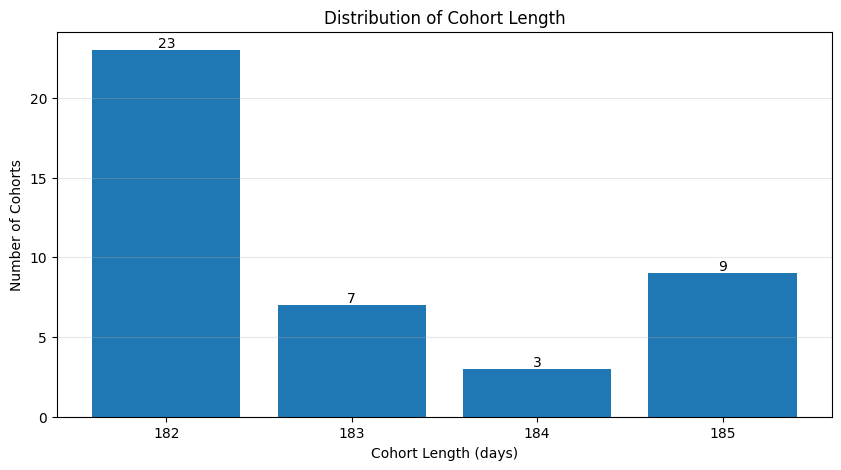

In [351]:
dist = (
    cohort_length['cohort_length']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    dist.index.astype(str),
    dist.values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xlabel('Cohort Length (days)')
plt.ylabel('Number of Cohorts')
plt.title('Distribution of Cohort Length')
plt.grid(axis='y', alpha=0.3)

plt.show()

Distribution of running revenue per cohort

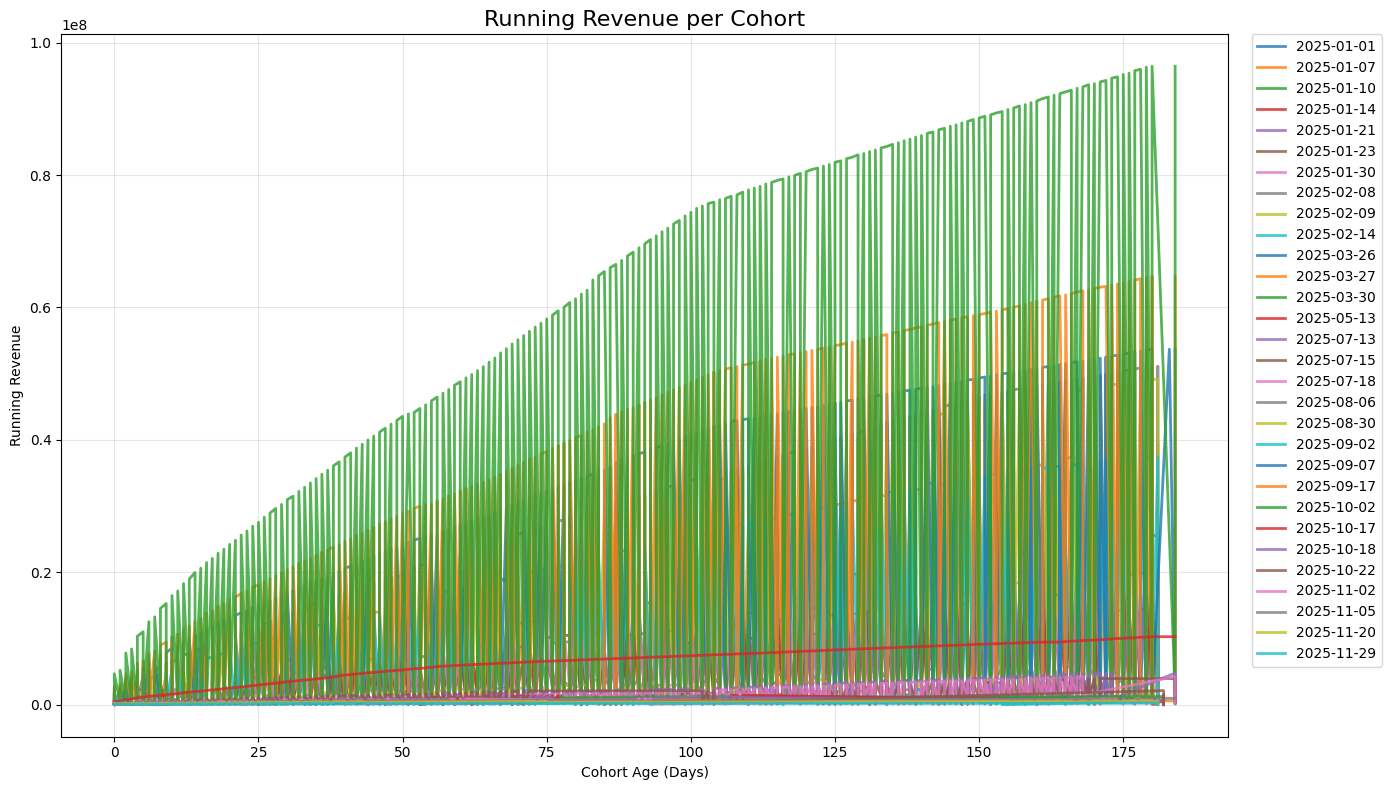

In [352]:
import matplotlib.pyplot as plt
import numpy as np

sample = (
    df['date_created_at']
    .drop_duplicates()
    .sample(30)
)

plt.figure(figsize=(14, 8))

for cohort in sorted(sample):
    temp = (
        df[df['date_created_at'] == cohort]
        .sort_values('cohort_age')
    )

    plt.plot(
        temp['cohort_age'],
        temp['revenue_running_total'],
        linewidth=2,
        alpha=0.8,
        label=cohort.strftime('%Y-%m-%d')
    )

plt.title("Running Revenue per Cohort", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Running Revenue")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

Average revenue daily push distribution per cohort age

<Axes: xlabel='cohort_age'>

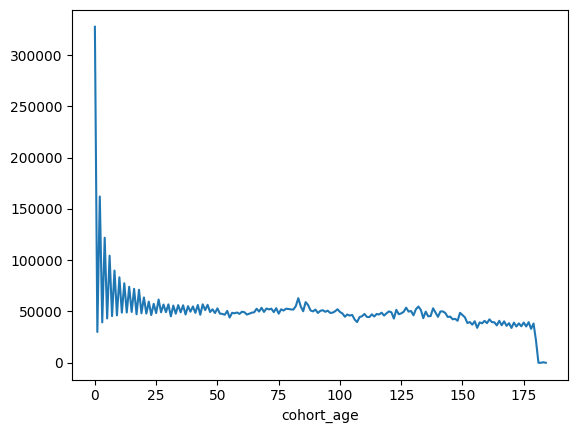

In [353]:
avg_daily = (
    df.groupby('cohort_age')['revenue_dailypush']
    .mean()
)

avg_daily.plot()

Average total revenue distribution per cohort age

<Axes: xlabel='cohort_age'>

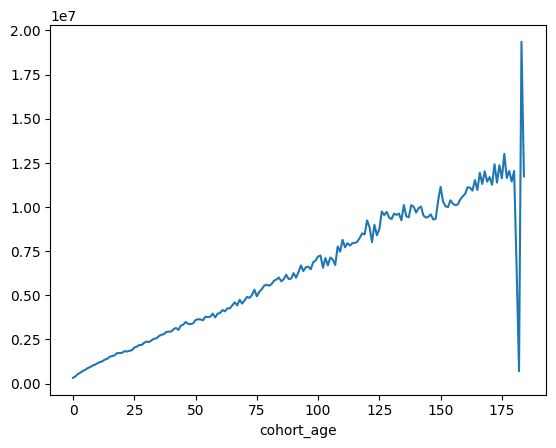

In [354]:
avg_running = (
    df.groupby('cohort_age')['revenue_running_total']
    .mean()
)

avg_running.plot()

Numerical correlation

<Axes: >

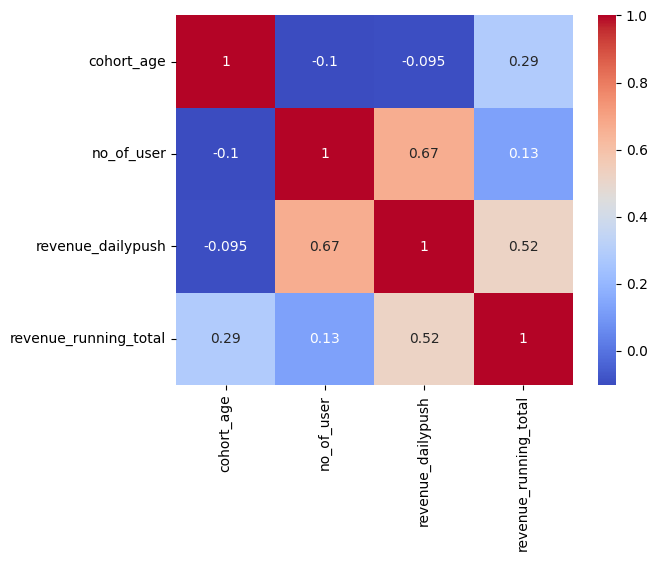

In [355]:
numeric_cols = [
    'cohort_age',
    'no_of_user',
    'revenue_dailypush',
    'revenue_running_total'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

## Preprocessing

### Sort Data

Final preparation with sorting date created and cohort age

In [356]:
df = (
    df
    .sort_values(
        ['date_created_at', 'cohort_age']
    )
    .reset_index(drop=True)
)

In [357]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,weekend,day_of_month
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0,2,0,1
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,0,1
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0,2,0,1
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0,2,0,1
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1,3,0,2


### Encoding

Create new dataframe for preprocessing process

In [358]:
df_model = df.copy()

subject_encoder = LabelEncoder()
adnet_encoder = LabelEncoder()

Subject encoding

In [359]:
df_model['subject_encoded'] = subject_encoder.fit_transform(df_model['subject'])

In [360]:
df_model.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,weekend,day_of_month,subject_encoded
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0,2,0,1,1
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,0,1,1
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0,2,0,1,1
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0,2,0,1,1
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1,3,0,2,0


Adnet encoding

In [361]:
df_model['adnet_encoded'] = adnet_encoder.fit_transform(df_model['adnet'])

In [362]:
df_model.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,weekend,day_of_month,subject_encoded,adnet_encoded
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0,2,0,1,1,1
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,0,1,1,2
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0,2,0,1,1,0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0,2,0,1,1,4
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1,3,0,2,0,4


### Feature Selection

Selecting feature for new dataframe

In [363]:
KEEP_COLS = [
    'date_created_at',
    'cohort_age',
    'revenue_running_total',
    'revenue_dailypush',
    'no_of_user',
    'day_of_week',
    'weekend',
    'day_of_month',
    'subject_encoded',
    'adnet_encoded'
]

df_model = df_model[KEEP_COLS]

In [364]:
df_model.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,weekend,day_of_month,subject_encoded,adnet_encoded
0,2025-01-01,0,6000.0,6000.0,86,2,0,1,1,1
1,2025-01-01,0,136000.0,136000.0,686,2,0,1,1,2
2,2025-01-01,0,1054000.0,1054000.0,2662,2,0,1,1,0
3,2025-01-01,0,68000.0,68000.0,596,2,0,1,1,4
4,2025-01-01,1,84000.0,16000.0,8,3,0,2,0,4


### Split Data

Split to train 80% and validation 20% from total cohorts

In [365]:
cohorts = sorted(df_model['date_created_at'].unique())

split_idx = int(len(cohorts) * 0.8)

train_cohorts = cohorts[:split_idx]
val_cohorts = cohorts[split_idx:]

In [366]:
print("Total Train Cohort:", len(train_cohorts))
print("Sample Train Cohort:", train_cohorts)

print("Total Val Cohort:", len(val_cohorts))
print("Sample Val Cohort:", val_cohorts)

Total Train Cohort: 33
Sample Train Cohort: [Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-07 00:00:00'), Timestamp('2025-01-10 00:00:00'), Timestamp('2025-01-14 00:00:00'), Timestamp('2025-01-20 00:00:00'), Timestamp('2025-01-21 00:00:00'), Timestamp('2025-01-23 00:00:00'), Timestamp('2025-01-28 00:00:00'), Timestamp('2025-01-30 00:00:00'), Timestamp('2025-02-03 00:00:00'), Timestamp('2025-02-08 00:00:00'), Timestamp('2025-02-09 00:00:00'), Timestamp('2025-02-10 00:00:00'), Timestamp('2025-02-14 00:00:00'), Timestamp('2025-02-17 00:00:00'), Timestamp('2025-03-08 00:00:00'), Timestamp('2025-03-26 00:00:00'), Timestamp('2025-03-27 00:00:00'), Timestamp('2025-03-30 00:00:00'), Timestamp('2025-04-21 00:00:00'), Timestamp('2025-05-13 00:00:00'), Timestamp('2025-06-03 00:00:00'), Timestamp('2025-06-24 00:00:00'), Timestamp('2025-07-13 00:00:00'), Timestamp('2025-07-15 00:00:00'), Timestamp('2025-07-18 00:00:00'), Timestamp('2025-08-06 00:00:00'), Timestamp('2025-08-30 00:00:00'), Tim

Insert to pandas for next step (scaling)

In [367]:
train_df = df_model[df_model['date_created_at'].isin(train_cohorts)]
val_df = df_model[df_model['date_created_at'].isin(val_cohorts)]

In [368]:
train_df.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,weekend,day_of_month,subject_encoded,adnet_encoded
0,2025-01-01,0,6000.0,6000.0,86,2,0,1,1,1
1,2025-01-01,0,136000.0,136000.0,686,2,0,1,1,2
2,2025-01-01,0,1054000.0,1054000.0,2662,2,0,1,1,0
3,2025-01-01,0,68000.0,68000.0,596,2,0,1,1,4
4,2025-01-01,1,84000.0,16000.0,8,3,0,2,0,4


### Scaling

Setup feature and target for training

In [369]:
FEATURES = [
    'revenue_running_total',
    'cohort_age',
    'day_of_week',
    'weekend',
    'day_of_month',
]

TARGET = 'revenue_running_total'

Scaling to make better input in time series model, using min-max scaler

In [370]:
scaler = MinMaxScaler()

# Fit on train only
train_df = train_df.copy()
val_df   = val_df.copy()

train_df[FEATURES] = scaler.fit_transform(train_df[FEATURES])
val_df[FEATURES]   = scaler.transform(val_df[FEATURES])

Checking data train

In [371]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14614 entries, 0 to 14613
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        14614 non-null  datetime64[ns]
 1   cohort_age             14614 non-null  float64       
 2   revenue_running_total  14614 non-null  float64       
 3   revenue_dailypush      14614 non-null  float64       
 4   no_of_user             14614 non-null  Int64         
 5   day_of_week            14614 non-null  float64       
 6   weekend                14614 non-null  float64       
 7   day_of_month           14614 non-null  float64       
 8   subject_encoded        14614 non-null  int64         
 9   adnet_encoded          14614 non-null  int64         
dtypes: Int64(1), datetime64[ns](1), float64(6), int64(2)
memory usage: 1.2 MB


In [372]:
train_df.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,weekend,day_of_month,subject_encoded,adnet_encoded
0,2025-01-01,0.000000,0.000062,6000.0,86,0.333333,0.0,0.000000,1,1
1,2025-01-01,0.000000,0.001410,136000.0,686,0.333333,0.0,0.000000,1,2
2,2025-01-01,0.000000,0.010931,1054000.0,2662,0.333333,0.0,0.000000,1,0
3,2025-01-01,0.000000,0.000705,68000.0,596,0.333333,0.0,0.000000,1,4
4,2025-01-01,0.005435,0.000871,16000.0,8,0.500000,0.0,0.033333,0,4


Checking data validation

In [373]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464 entries, 14614 to 16077
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        1464 non-null   datetime64[ns]
 1   cohort_age             1464 non-null   float64       
 2   revenue_running_total  1464 non-null   float64       
 3   revenue_dailypush      1464 non-null   float64       
 4   no_of_user             1464 non-null   Int64         
 5   day_of_week            1464 non-null   float64       
 6   weekend                1464 non-null   float64       
 7   day_of_month           1464 non-null   float64       
 8   subject_encoded        1464 non-null   int64         
 9   adnet_encoded          1464 non-null   int64         
dtypes: Int64(1), datetime64[ns](1), float64(6), int64(2)
memory usage: 127.2 KB


In [374]:
val_df.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,weekend,day_of_month,subject_encoded,adnet_encoded
14614,2025-10-17,0.000000,0.002012,194000.0,2082,0.666667,0.0,0.533333,1,3
14615,2025-10-17,0.000000,0.000021,2000.0,16,0.666667,0.0,0.533333,1,4
14616,2025-10-17,0.000000,0.000767,74000.0,515,0.666667,0.0,0.533333,1,2
14617,2025-10-17,0.010870,0.002033,2000.0,1,1.000000,1.0,0.600000,0,3
14618,2025-10-17,0.016304,0.002136,10000.0,5,0.000000,0.0,0.633333,0,3


## Sequence Generation

### Sliding Window

Setup window size with 30 days and build sequence per cohort **and adnet** (grouped by `date_created_at` + `adnet_encoded`) so windows never mix data across different adnets

In [375]:
WINDOW_SIZE = 30

def create_sequences(data, features, target, window_size, group_cols=('date_created_at', 'adnet_encoded')):

    X = []
    y = []

    group_cols = list(group_cols)

    # Group by cohort AND adnet so sequences never mix data across adnets
    for _, group_df in data.groupby(group_cols):

        group_df = group_df.sort_values('cohort_age')
        feature_values = group_df[features].values
        target_values = group_df[target].values

        for i in range(len(group_df) - window_size):

            X.append(feature_values[i:i+window_size])
            y.append(target_values[i+window_size])

    return np.array(X), np.array(y)

### Generate Sequence

In [376]:
X_train, y_train = create_sequences(
    train_df,
    FEATURES,
    TARGET,
    WINDOW_SIZE
)

X_val, y_val = create_sequences(
    val_df,
    FEATURES,
    TARGET,
    WINDOW_SIZE
)

Checking shape sequence

In [377]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

(11580, 30, 5)
(11580,)
(811, 30, 5)
(811,)


## Modeling

### LSTM

Building model

In [378]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [379]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 30, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,977 (511.63 KB)

 Trainable params: 130,977 (511.63 KB)

 Non-trainable params: 0 (0.00 B)

Compiler

In [380]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mape']
)

Training

In [381]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=200,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
362/362 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - loss: 0.0014 - mape: 137.9401 - val_loss: 2.5135e-05 - val_mape: 87.4567
Epoch 2/200
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - loss: 3.9688e-04 - mape: 87.1686 - val_loss: 2.2202e-05 - val_mape: 51.7173
Epoch 3/200
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - loss: 3.7771e-04 - mape: 88.8959 - val_loss: 1.3795e-05 - val_mape: 53.9495
Epoch 4/200
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - loss: 2.7795e-04 - mape: 79.7252 - val_loss: 1.3174e-05 - val_mape: 44.3568
Epoch 5/200
362/362 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - loss: 3.1603e-04 - mape: 87.7822 - val_loss: 3.8567e-05 - val_mape: 77.0382
Epoch 6/200
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - loss: 2.1438e-04 - mape: 74.0594 - val_loss: 1.5046e-04 - val_mape: 241.8322
Epoch 7/200
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - loss: 2.5924e-04 - mape: 78.2241 - val_loss: 1.1860e-05 - val_mape: 68.5109
Epoch 8/200
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - loss: 2.0386e-

## Evaluation

### Visualization

Loss visualization from training process

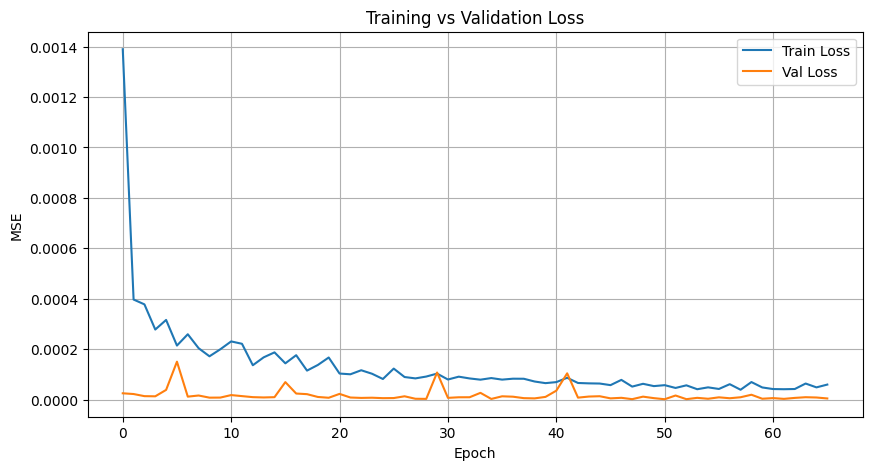

In [382]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.show()

MAPE visualization from training process

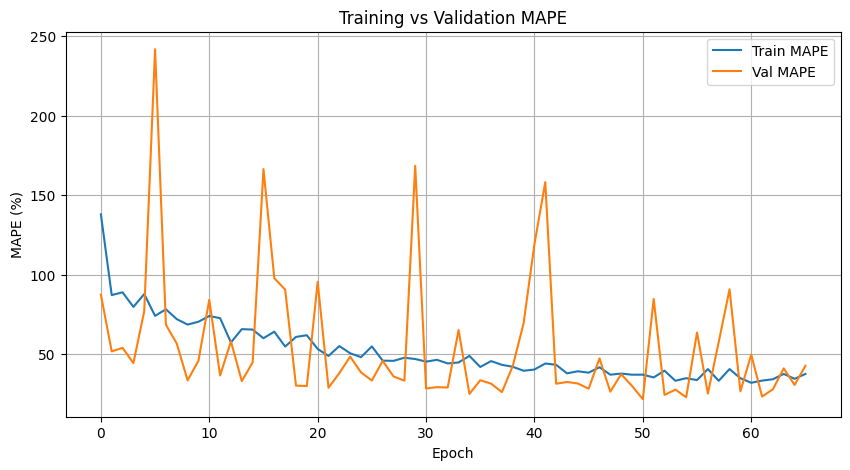

In [383]:
plt.figure(figsize=(10,5))

plt.plot(history.history['mape'], label='Train MAPE')
plt.plot(history.history['val_mape'], label='Val MAPE')

plt.title('Training vs Validation MAPE')
plt.xlabel('Epoch')
plt.ylabel('MAPE (%)')
plt.legend()
plt.grid(True)

plt.show()

In [384]:
y_pred = model.predict(X_val)
y_pred = y_pred.flatten()

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step


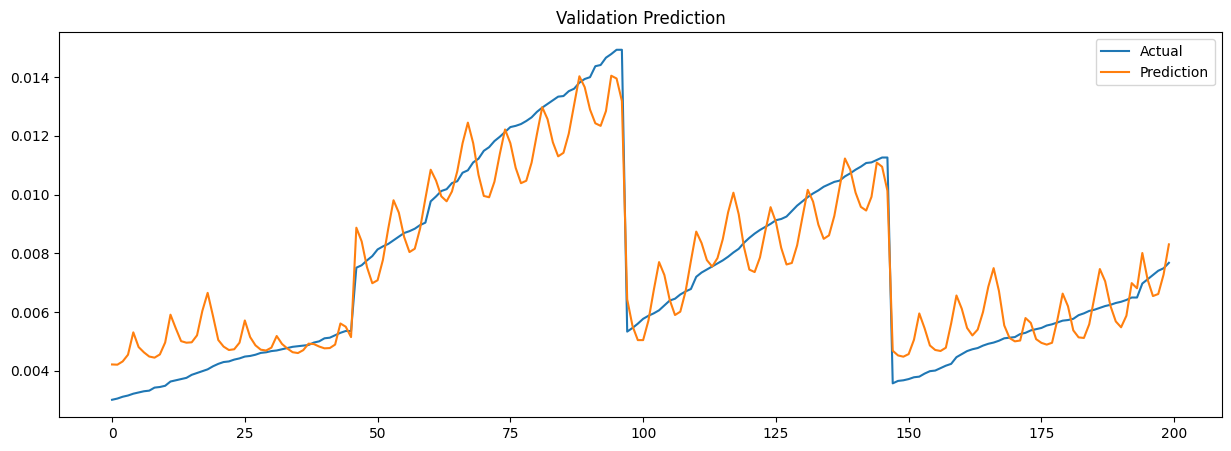

In [385]:
plt.figure(figsize=(15,5))

plt.plot(
    y_val[:200],
    label='Actual'
)

plt.plot(
    y_pred[:200],
    label='Prediction'
)

plt.title('Validation Prediction')

plt.legend()

plt.show()

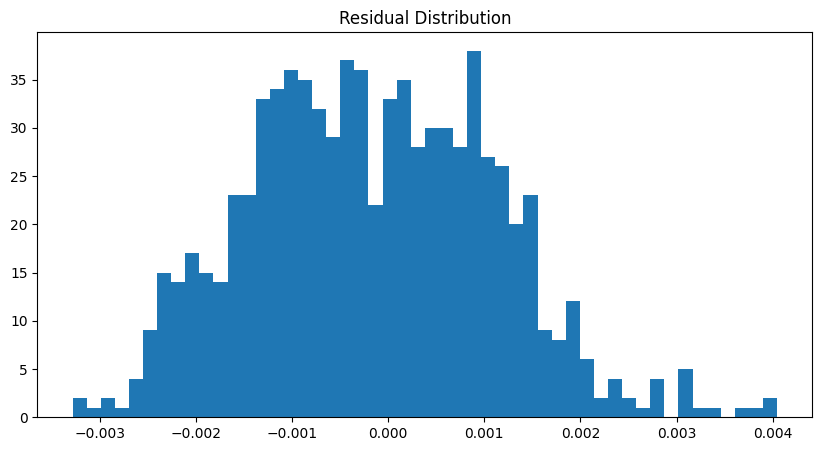

In [386]:
residuals = y_val - y_pred

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=50
)

plt.title('Residual Distribution')

plt.show()

### Metrics

Detail evaluation metrics in MAE, RMSE, MAPE

In [387]:
mae = mean_absolute_error(
    y_val,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred
    )
)

mape = mean_absolute_percentage_error(
    y_val,
    y_pred
) * 100

In [388]:
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 0.001045
RMSE : 0.001270
MAPE : 21.64%


## Projection

Recursive forecast: first `SEED_DAYS` as input seed, predict all remaining days in the cohort

In [389]:
def forecast_recursive(model, seed_window, future_features_scaled):
    """
    Recursive 1-step forecast.
    - seed_window           : (WINDOW_SIZE, n_features) scaled
    - future_features_scaled: (n_steps, n_features) — known-future cols (cohort_age,
                              day_of_week) pre-filled from val_df; target col = 0 placeholder
    """
    window     = seed_window.copy()
    preds      = []
    target_idx = FEATURES.index(TARGET)

    for i in range(len(future_features_scaled)):

        x = window.reshape(1, window.shape[0], window.shape[1])
        next_val_scaled = model.predict(x, verbose=0)[0, 0]

        preds.append(next_val_scaled)

        next_step = future_features_scaled[i].copy()
        next_step[target_idx] = next_val_scaled

        window = np.vstack([window[1:], next_step])

    return np.array(preds)

Select cohort and run projection

In [390]:
# cohort_age in val_df is scaled — use original df to check max age
# Build (cohort, adnet) candidate pairs so a single adnet series is forecast
candidates = []
for (cohort_c, adnet_c), g in (
    df[df['date_created_at'].isin(val_cohorts)].groupby(['date_created_at', 'adnet'])
):
    if int(g['cohort_age'].max()) >= SEED_DAYS:
        candidates.append((cohort_c, adnet_c))

print("Eligible (cohort, adnet) pairs:", len(candidates))

cohort, adnet = candidates[0]
adnet_code = adnet_encoder.transform([adnet])[0]

# Use original df for age-based slicing (unscaled cohort_age)
cohort_raw = (
    df[(df['date_created_at'] == cohort) & (df['adnet'] == adnet)]
    .sort_values('cohort_age')
    .reset_index(drop=True)
)

# Use scaled val_df for model input (same cohort AND adnet)
cohort_df = (
    val_df[(val_df['date_created_at'] == cohort) & (val_df['adnet_encoded'] == adnet_code)]
    .sort_values('cohort_age')
    .reset_index(drop=True)
)

seed_idx  = cohort_raw[cohort_raw['cohort_age'] < SEED_DAYS].index
seed_df   = cohort_df.iloc[:len(seed_idx)]
future_df = cohort_df.iloc[len(seed_idx):].reset_index(drop=True)
n_steps   = len(future_df)

seed = seed_df[FEATURES].values[-WINDOW_SIZE:]

# Future feature matrix: known-future cols from val_df (already scaled)
# target column is placeholder, filled step-by-step in forecast_recursive
future_features_scaled = future_df[FEATURES].values.copy()
future_features_scaled[:, FEATURES.index(TARGET)] = 0

print("Cohort      :", cohort)
print("Adnet       :", adnet)
print("Seed days   :", len(seed_df))
print("Future days :", n_steps)

pred_scaled = forecast_recursive(model, seed, future_features_scaled)

def inverse_target(scaled_vals):
    n      = len(scaled_vals)
    dummy  = np.zeros((n, len(FEATURES)))
    t_idx  = FEATURES.index(TARGET)
    dummy[:, t_idx] = scaled_vals
    return scaler.inverse_transform(dummy)[:, t_idx]

pred_running   = inverse_target(pred_scaled)
actual_running = inverse_target(future_df[FEATURES].values[:, FEATURES.index(TARGET)])

print(f"Predicted running total at day {SEED_DAYS + n_steps - 1}: {pred_running[-1]:,.0f}")
print(f"Actual   running total at day {SEED_DAYS + n_steps - 1}: {actual_running[-1]:,.0f}")

Eligible (cohort, adnet) pairs: 25
Cohort      : 2025-10-17 00:00:00
Adnet       : MBP
Seed days   : 56
Future days : 20
Predicted running total at day 79: 493,539
Actual   running total at day 79: 516,000


Evaluation at day+30, day+60, and full horizon

In [391]:
milestones = {'day+30': 30, 'day+60': 60, 'full': n_steps}

for label, days in milestones.items():
    n = min(days, len(actual_running), len(pred_running))
    if n == 0:
        print(f"{label}: not enough data")
        continue
    mae  = mean_absolute_error(actual_running[:n], pred_running[:n])
    rmse = np.sqrt(mean_squared_error(actual_running[:n], pred_running[:n]))
    mape = mean_absolute_percentage_error(actual_running[:n], pred_running[:n]) * 100
    print(f"[{label:>7}] MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  MAPE={mape:.2f}%")

[ day+30] MAE=      21,635  RMSE=      27,120  MAPE=4.64%
[ day+60] MAE=      21,635  RMSE=      27,120  MAPE=4.64%
[   full] MAE=      21,635  RMSE=      27,120  MAPE=4.64%


Actual vs projection visualization

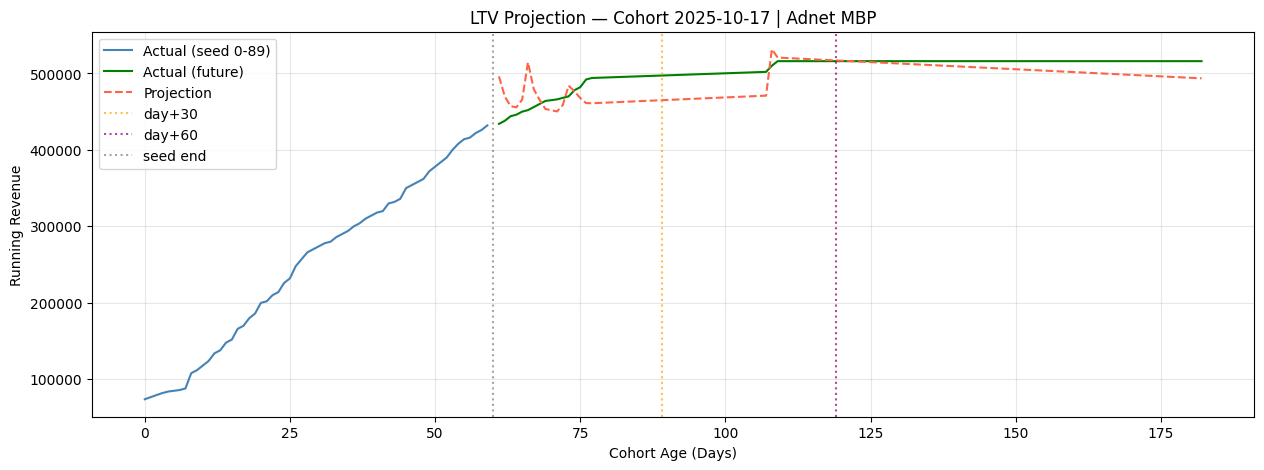

In [392]:
seed_running = inverse_target(seed_df[FEATURES].values[:, FEATURES.index(TARGET)])

# cohort_age is scaled in val_df — use original df for x-axis values
seed_age   = cohort_raw[cohort_raw['cohort_age'] < SEED_DAYS]['cohort_age'].values
future_age = cohort_raw[cohort_raw['cohort_age'] >= SEED_DAYS]['cohort_age'].values[:n_steps]
pred_age   = future_age[:len(pred_running)]

plt.figure(figsize=(15, 5))

plt.plot(seed_age,   seed_running,   label='Actual (seed 0-89)',  color='steelblue')
plt.plot(future_age, actual_running, label='Actual (future)',      color='green')
plt.plot(pred_age,   pred_running,   label='Projection',           color='tomato', linestyle='--')

for offset, color in [(30, 'orange'), (60, 'purple')]:
    day = SEED_DAYS + offset - 1
    if len(future_age) > 0 and day <= future_age[-1]:
        plt.axvline(x=day, color=color, linestyle=':', alpha=0.7, label=f'day+{offset}')

plt.axvline(x=SEED_DAYS, color='gray', linestyle=':', alpha=0.7, label='seed end')
plt.title(f'LTV Projection — Cohort {str(cohort)[:10]} | Adnet {adnet}')
plt.xlabel('Cohort Age (Days)')
plt.ylabel('Running Revenue')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Testing on Unseen Data

This section evaluates the trained LSTM model on a completely hold-out dataset (`linkit-rnd-475909.country_summary.ml_lstm_unseen_5cohorts`) containing 5 unseen cohorts that were never seen during training or validation.

Unlike TimeFM, the LSTM is a **supervised, multivariate** model trained on scaled features. The unseen data must therefore go through the **same preprocessing pipeline** as the training data:

- Feature engineering: `cohort_age`, `day_of_week`, `weekend`, `day_of_month`, subject/adnet encoding
- Scaling using `scaler.transform()` (the scaler fitted on training data — **no re-fitting** to avoid data leakage)
- Sliding window construction and recursive forecasting

The `inverse_target()` helper and `forecast_recursive()` function defined in the Projection section are reused here.

### Loader

Query the unseen testing table from Google BigQuery

In [393]:
df_unseen = pd.read_gbq(unseen_query, project_id=project_id, dialect='standard')
df_unseen.head()

/tmp/ipykernel_18195/1259746139.py:1: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_unseen = pd.read_gbq(unseen_query, project_id=project_id, dialect='standard')


,date_created_at,camp_sub_keyword,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
0,2025-04-06,NON,MBP,2025-04-06,1569,240000.0,FIRSTPUSH,240000.0
1,2025-04-06,NON,MBP,2025-04-07,11,22000.0,DAILYPUSH,262000.0
2,2025-04-06,NON,MBP,2025-04-08,31,62000.0,DAILYPUSH,324000.0
3,2025-04-06,NON,MBP,2025-04-09,9,18000.0,DAILYPUSH,342000.0
4,2025-04-06,NON,MBP,2025-04-10,21,42000.0,DAILYPUSH,384000.0


### Feature Engineering

Apply the same feature engineering as the training data: parse dates, compute `cohort_age`, add `day_of_week`, `weekend`, `day_of_month`, and sort. This is required because the LSTM was trained on these features.

In [394]:
df_unseen['date_created_at'] = pd.to_datetime(df_unseen['date_created_at'])
df_unseen['date_update']     = pd.to_datetime(df_unseen['date_update'])

df_unseen['cohort_age'] = (
    df_unseen['date_update'] - df_unseen['date_created_at']
).dt.days

df_unseen['day_of_week'] = df_unseen['date_update'].dt.dayofweek
df_unseen['weekend'] = (df_unseen['date_update'].dt.dayofweek >= 5).astype(int)
df_unseen['day_of_month'] = df_unseen['date_update'].dt.day

df_unseen = (
    df_unseen
    .sort_values(['date_created_at', 'cohort_age'])
    .reset_index(drop=True)
)

df_unseen.head()

,date_created_at,camp_sub_keyword,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,weekend,day_of_month
0,2025-04-06,NON,MBP,2025-04-06,1569,240000.0,FIRSTPUSH,240000.0,0,6,1,6
1,2025-04-06,NON,MBP,2025-04-07,11,22000.0,DAILYPUSH,262000.0,1,0,0,7
2,2025-04-06,NON,MBP,2025-04-08,31,62000.0,DAILYPUSH,324000.0,2,1,0,8
3,2025-04-06,NON,MBP,2025-04-09,9,18000.0,DAILYPUSH,342000.0,3,2,0,9
4,2025-04-06,NON,MBP,2025-04-10,21,42000.0,DAILYPUSH,384000.0,4,3,0,10


Subject and adnet encoding using the encoders fitted on training data

In [395]:
df_unseen['subject_encoded'] = subject_encoder.transform(df_unseen['subject'])
df_unseen['adnet_encoded']   = adnet_encoder.transform(df_unseen['adnet'])

Feature selection — keep the same columns as the training data

In [396]:
df_unseen_model = df_unseen[KEEP_COLS].copy()

Checking unseen cohorts and their length

In [397]:
unseen_cohorts = sorted(df_unseen_model['date_created_at'].unique())

print("Total unseen cohorts:", len(unseen_cohorts))
for c in unseen_cohorts:
    days = int(df_unseen[df_unseen['date_created_at'] == c]['cohort_age'].max()) + 1
    print(f"  {str(c)[:10]} -> {days} days")

Total unseen cohorts: 5
  2025-04-06 -> 184 days
  2025-08-04 -> 185 days
  2025-08-21 -> 185 days
  2025-09-22 -> 182 days
  2025-10-31 -> 182 days


### Scaling

Apply `scaler.transform()` using the scaler already fitted on the training data. **Do not call `fit_transform()`** here — that would leak unseen data statistics into the scaler and invalidate the test.

In [398]:
df_unseen_model = df_unseen_model.copy()
df_unseen_model[FEATURES] = scaler.transform(df_unseen_model[FEATURES])

df_unseen_model.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,weekend,day_of_month,subject_encoded,adnet_encoded
0,2025-04-06,0.000000,0.002489,240000.0,1569,1.000000,1.0,0.166667,1,2
1,2025-04-06,0.005435,0.002717,22000.0,11,0.000000,0.0,0.200000,0,2
2,2025-04-06,0.010870,0.003360,62000.0,31,0.166667,0.0,0.233333,0,2
3,2025-04-06,0.016304,0.003547,18000.0,9,0.333333,0.0,0.266667,0,2
4,2025-04-06,0.021739,0.003982,42000.0,21,0.500000,0.0,0.300000,0,2


### Visualization

Distribution of running revenue per cohort

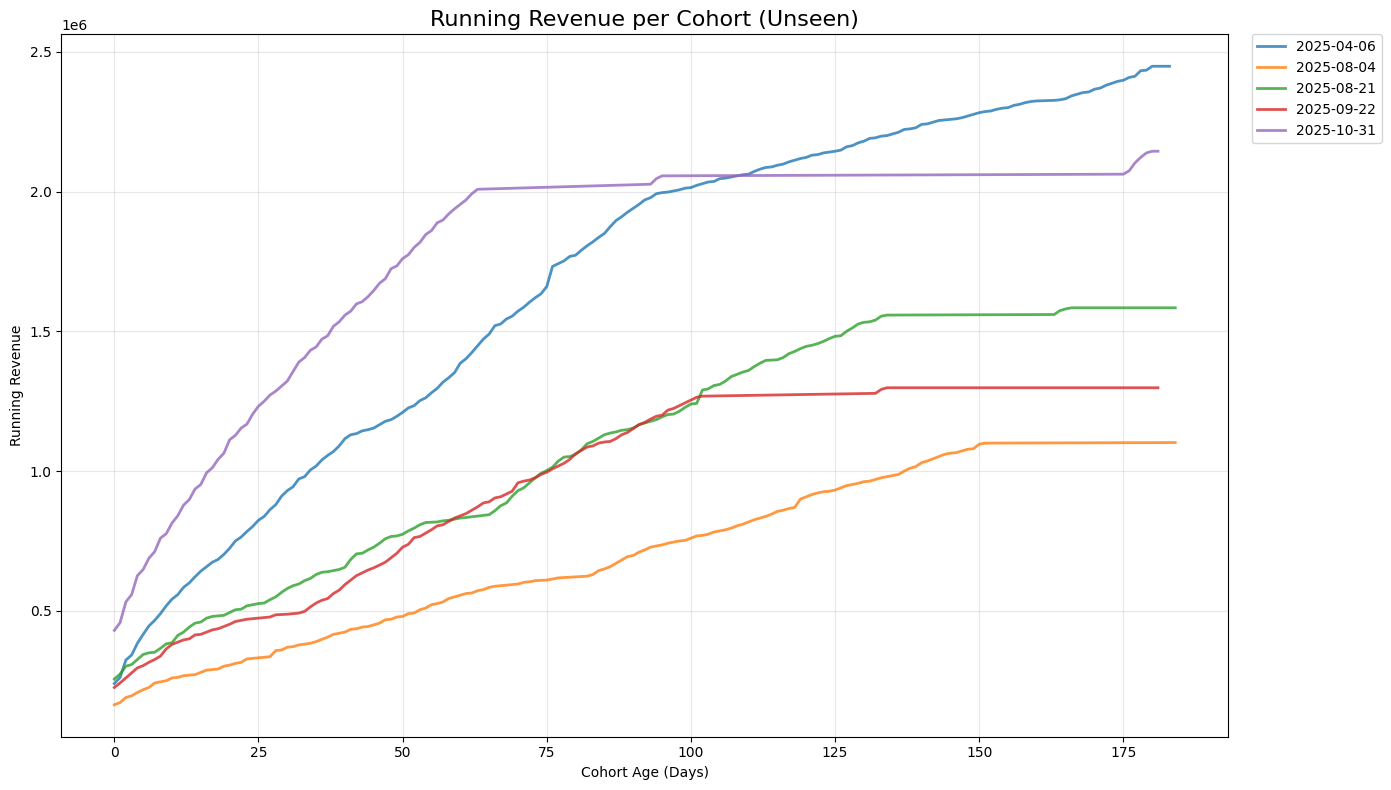

In [399]:
plt.figure(figsize=(14, 8))

for cohort in unseen_cohorts:
    temp = (
        df_unseen[df_unseen['date_created_at'] == cohort]
        .sort_values('cohort_age')
    )

    plt.plot(
        temp['cohort_age'],
        temp['revenue_running_total'],
        linewidth=2,
        alpha=0.8,
        label=pd.Timestamp(cohort).strftime('%Y-%m-%d')
    )

plt.title("Running Revenue per Cohort (Unseen)", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Running Revenue")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

### Forecast

For each unseen (cohort, adnet) pair, use the first `SEED_DAYS` days as the seed window and apply the same `forecast_recursive()` function used in the Projection section. The seed window is taken from the **scaled** `df_unseen_model`, while `cohort_age` for the x-axis is read from the **unscaled** `df_unseen`. Each adnet is forecast separately so series are never mixed.

In [400]:
results_unseen = {}

# Iterate over (cohort, adnet) pairs so each adnet series is forecast separately
for (cohort, adnet), cohort_raw in (
    df_unseen.groupby(['date_created_at', 'adnet'])
):

    # Unscaled — for age-based slicing and x-axis
    cohort_raw = (
        cohort_raw
        .sort_values('cohort_age')
        .reset_index(drop=True)
    )

    adnet_code = adnet_encoder.transform([adnet])[0]

    # Scaled — model input (same cohort AND adnet)
    cohort_scaled = (
        df_unseen_model[
            (df_unseen_model['date_created_at'] == cohort)
            & (df_unseen_model['adnet_encoded'] == adnet_code)
        ]
        .sort_values('cohort_age')
        .reset_index(drop=True)
    )

    if len(cohort_raw) <= WINDOW_SIZE:
        # Not enough history to build a seed window — skip
        continue

    seed_len  = min(SEED_DAYS, len(cohort_raw) - 1)
    seed_idx  = cohort_raw[cohort_raw['cohort_age'] < seed_len].index

    seed_df_u   = cohort_scaled.iloc[:len(seed_idx)]
    future_df_u = cohort_scaled.iloc[len(seed_idx):].reset_index(drop=True)
    n_steps     = len(future_df_u)

    if n_steps == 0:
        continue

    seed = seed_df_u[FEATURES].values[-WINDOW_SIZE:]

    future_features_scaled_u = future_df_u[FEATURES].values.copy()
    future_features_scaled_u[:, FEATURES.index(TARGET)] = 0

    pred_scaled_u = forecast_recursive(model, seed, future_features_scaled_u)

    pred_running_u   = inverse_target(pred_scaled_u)
    actual_running_u = inverse_target(
        future_df_u[FEATURES].values[:, FEATURES.index(TARGET)]
    )

    results_unseen[(cohort, adnet)] = {
        'cohort_raw': cohort_raw,
        'adnet': adnet,
        'seed_len': seed_len,
        'seed_df': seed_df_u,
        'pred_running': pred_running_u,
        'actual_running': actual_running_u,
        'n_steps': n_steps,
    }

    # Calculate MAPE for full horizon
    mape_full = mean_absolute_percentage_error(actual_running_u, pred_running_u) * 100
    print(f"{str(cohort)[:10]} | {adnet}: seed={seed_len}d, forecast={n_steps}d  | final pred={pred_running_u[-1]:,.0f}  actual={actual_running_u[-1]:,.0f}  MAPE={mape_full:.2f}%")

2025-04-06 | MBP: seed=60d, forecast=117d  | final pred=979,357  actual=2,448,000  MAPE=52.33%
2025-08-04 | MBP: seed=60d, forecast=85d  | final pred=720,251  actual=1,102,000  MAPE=32.44%
2025-08-21 | MBP: seed=60d, forecast=76d  | final pred=600,599  actual=1,584,000  MAPE=50.03%
2025-09-22 | MBP: seed=60d, forecast=47d  | final pred=650,213  actual=1,298,000  MAPE=25.29%
2025-10-31 | MBP: seed=60d, forecast=14d  | final pred=1,230,134  actual=2,144,000  MAPE=19.56%


Actual vs projection visualization for each unseen cohort

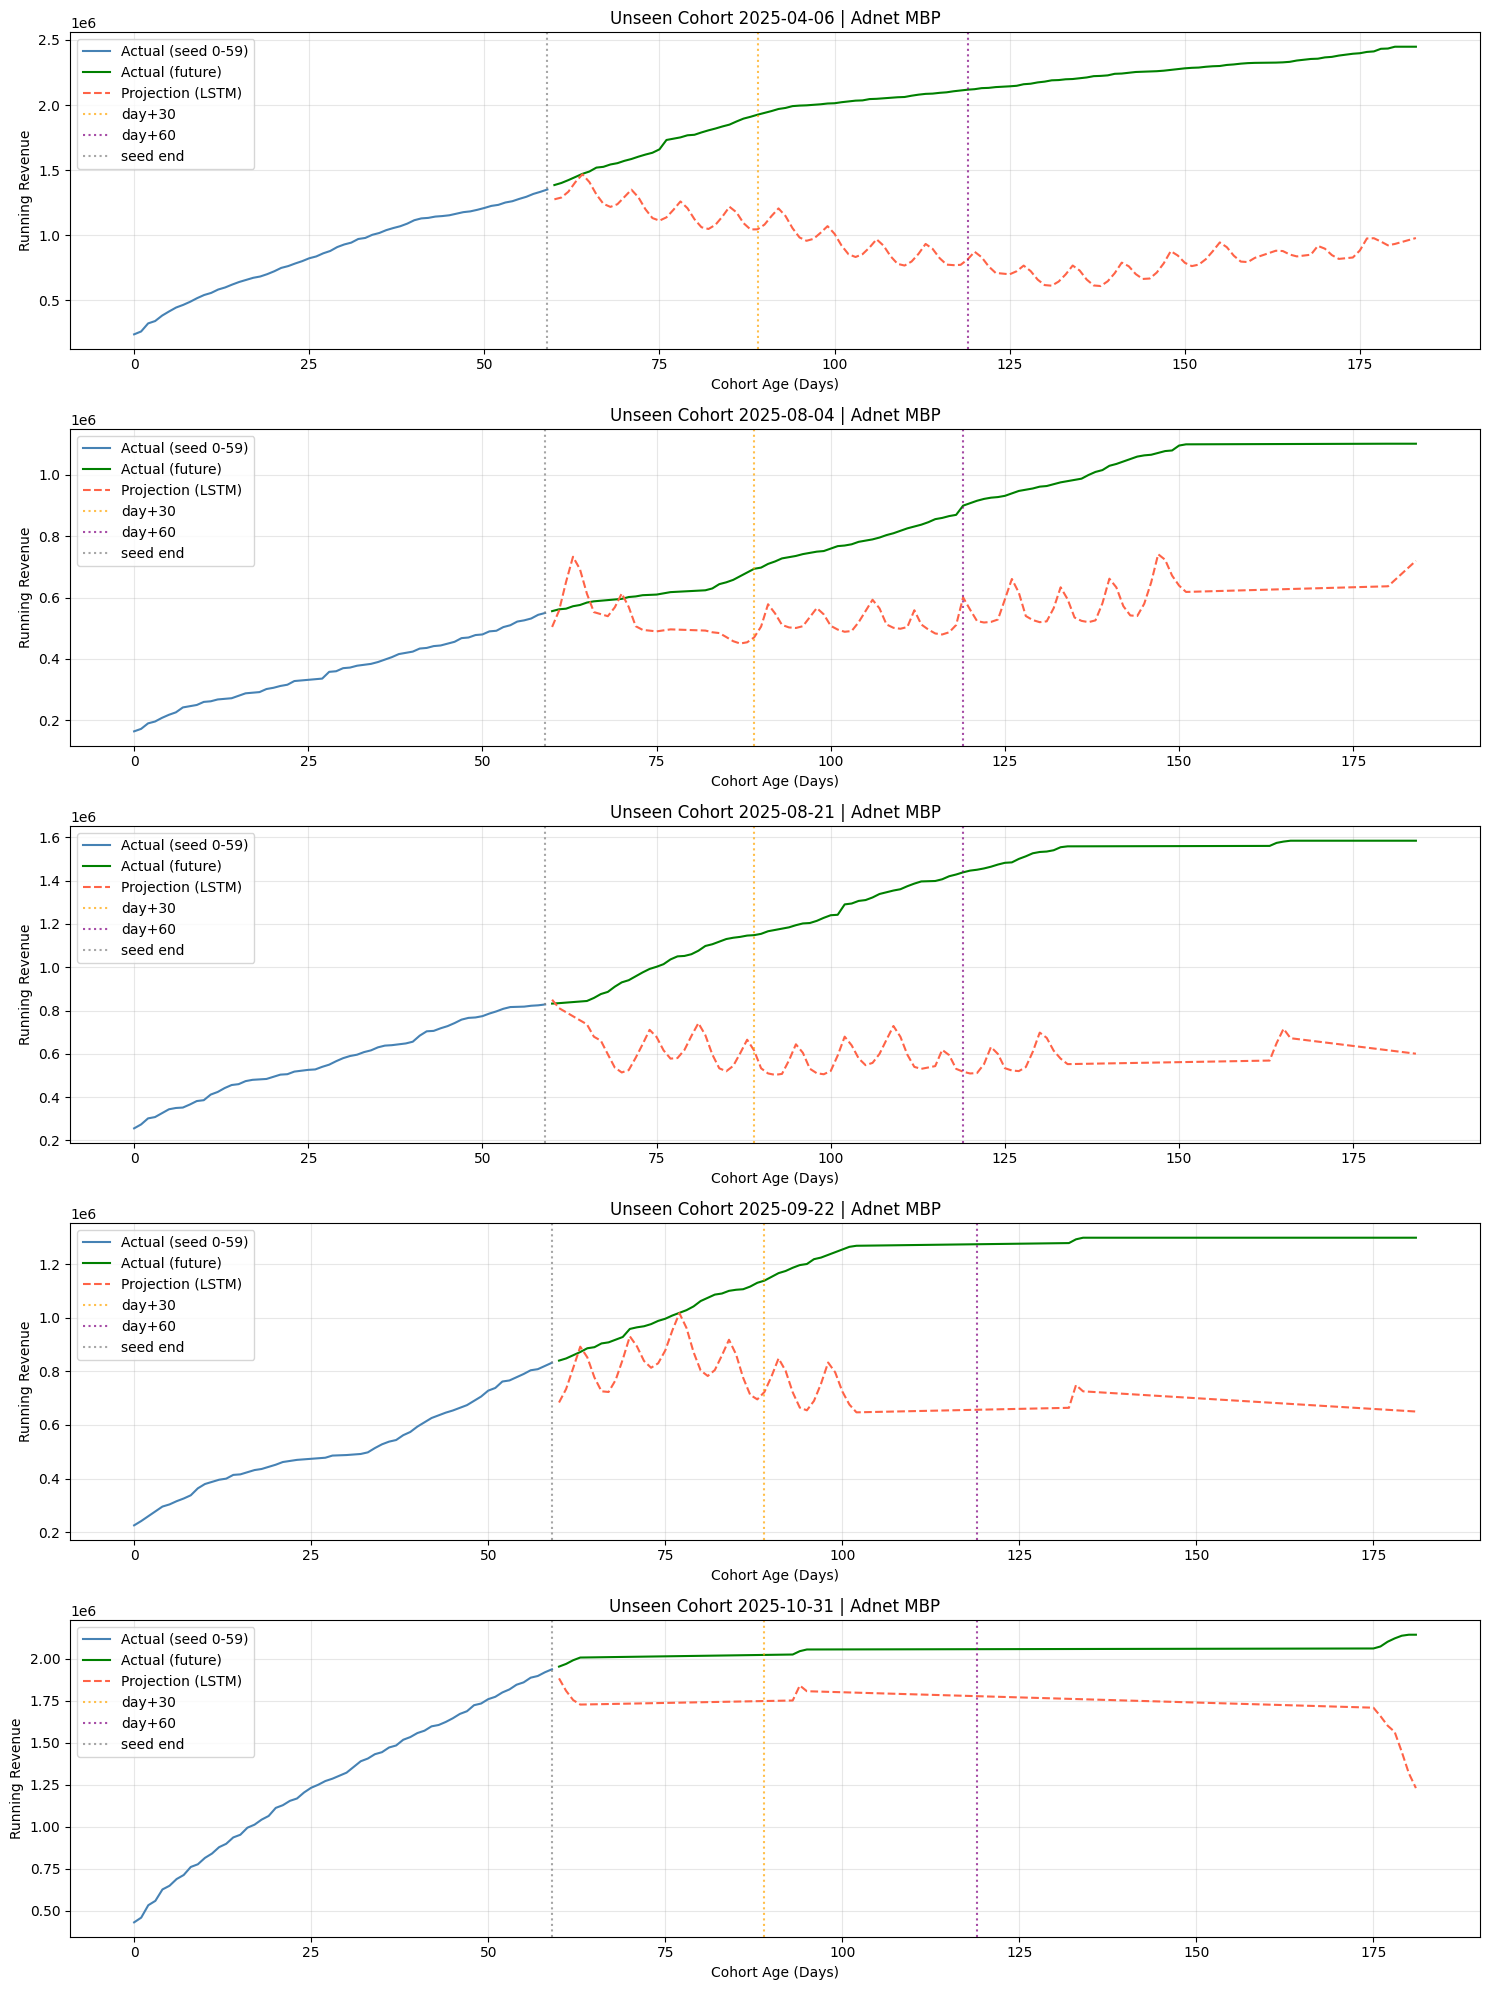

In [401]:
n_cohorts = len(results_unseen)
fig, axes = plt.subplots(n_cohorts, 1, figsize=(15, 4 * n_cohorts))

if n_cohorts == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(axes, results_unseen.items()):
    cohort_raw = r['cohort_raw']
    seed_len   = r['seed_len']
    n_steps    = r['n_steps']

    seed_running_u = inverse_target(
        r['seed_df'][FEATURES].values[:, FEATURES.index(TARGET)]
    )

    seed_age   = cohort_raw[cohort_raw['cohort_age'] < seed_len]['cohort_age'].values
    future_age = cohort_raw[cohort_raw['cohort_age'] >= seed_len]['cohort_age'].values[:n_steps]
    pred_age   = future_age[:len(r['pred_running'])]

    ax.plot(seed_age,   seed_running_u,    label=f'Actual (seed 0-{seed_len-1})', color='steelblue')
    ax.plot(future_age, r['actual_running'],label='Actual (future)',              color='green')
    ax.plot(pred_age,   r['pred_running'],  label='Projection (LSTM)',            color='tomato', linestyle='--')

    for offset, color in [(30, 'orange'), (60, 'purple')]:
        day = seed_len + offset - 1
        if len(future_age) > 0 and day <= future_age[-1]:
            ax.axvline(x=day, color=color, linestyle=':', alpha=0.7, label=f'day+{offset}')

    if len(seed_age) > 0:
        ax.axvline(x=seed_age[-1], color='gray', linestyle=':', alpha=0.7, label='seed end')

    ax.set_title(f'Unseen Cohort {str(cohort)[:10]} | Adnet {adnet}')
    ax.set_xlabel('Cohort Age (Days)')
    ax.set_ylabel('Running Revenue')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()